In [1]:
import pandas as pd
import numpy as np

DATA DESCRIPTION
```
file name -> Columns
quater-i.csv -> ['order_id', 'quantity', 'item_id', 'choice_description_id' 'item_price']
items.csv -> ['item_id', 'item_name']
```
Dataset Link - https://drive.google.com/drive/folders/1Z0kaFybvgFeczeUj4dldUnhTdloLqLsL?usp=share_link

In [2]:
# import like this
items_path = "datasets/data_task_20/items.csv"
q1_path = "datasets/data_task_20/quarter-1.csv"
q2_path = "datasets/data_task_20/quarter-2.csv"
q3_path = "datasets/data_task_20/quarter-3.csv"


q1 = pd.read_csv(q1_path)
q2 = pd.read_csv(q2_path)
q3 = pd.read_csv(q3_path)

items = pd.read_csv(items_path)

q1.head(5)

,order_id,quantity,item_id,choice_description_id,item_price
0,1,1,1,1,$3.39
1,1,1,2,2,$3.39
2,2,2,4,3,$16.98
3,4,1,7,6,$9.25
4,6,1,9,8,$8.75


### `Q:1-5`
1. You are given three quater files, your job is to append these three files and make a single dataframe.
2. Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
3. Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
4. Find out items which has made most revenue in each quarter.
5. Find out avg order price of each quarter.

***Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.***

In [3]:
# code here

q1['quarter'] = 'Q1'
q2['quarter'] = 'Q2'
q3['quarter'] = 'Q3'

# 1
df = pd.concat([q1, q2, q3], ignore_index=True)
df.sample(5)

# 2
df['item_price'] = df['item_price'].str.replace('$','', regex=False).astype(float)
df = df.merge(items, on='item_id')

# 3
most_sold = (
    df.groupby(['quarter', 'item_name'])['quantity']
    .sum()
    .reset_index()
    .sort_values(['quarter', 'quantity'], ascending=[True, False])
    .groupby('quarter')
    .head(1)
)

print(most_sold)

# 4 
df['revenue'] = df['quantity'] * df['item_price']

top_revenue = (
    df.groupby(['quarter', 'item_name'])['revenue']
    .sum()
    .reset_index()
    .sort_values(['quarter', 'revenue'], ascending=[True, False])
    .groupby('quarter')
    .head(1)
)

print(top_revenue)

# 5 
order_total = (
    df.groupby(['quarter', 'order_id'])['revenue']
    .sum()
    .reset_index()
)

avg_order_price = order_total.groupby('quarter')['revenue'].mean()

print(avg_order_price)

   quarter     item_name quantity
17      Q1  Chicken Bowl      367
65      Q2  Chicken Bowl      394
   quarter     item_name  revenue
17      Q1  Chicken Bowl  3852.38
65      Q2  Chicken Bowl  4192.25
quarter
Q1    13.809488
Q2    13.279828
Name: revenue, dtype: object


### `Q-6` From the IPL wala dataset you have to find the Purple cap holder each season.

*Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.*

Bowler's Economy = runs-conceded per six balls

In [4]:
matches = pd.read_csv("datasets/IPL_Matches_2008_2022.csv")
df = pd.read_csv("datasets/ipl_deliveries.csv")
df = df.merge(matches[['ID','Season']], on='ID')

In [5]:
# code here

dismissals = df[(df['isWicketDelivery']==0) & (df['kind']!='run out')]

bowler_stats = df.groupby(['Season','bowler']).agg(
    wickets=('isWicketDelivery','sum'),
    runs_conceded=('total_run','sum'),
    balls=('ballnumber','count')
).reset_index()

bowler_stats['economy'] = (bowler_stats['runs_conceded']/bowler_stats['balls'])*6

bowler_stats = bowler_stats.sort_values(
    ['Season','wickets','economy'],
    ascending=[True, False, True]
)

purple_cap = bowler_stats.groupby('Season').first().reset_index()

print(purple_cap[['Season','bowler','wickets','economy']])

     Season         bowler  wickets   economy
0   2007/08  Sohail Tanvir       24  6.226415
1      2009       RP Singh       26  6.753927
2   2009/10        PP Ojha       22  7.316667
3      2011     SL Malinga       30  5.939547
4      2012       M Morkel       30  7.187661
5      2013       DJ Bravo       34  7.729592
6      2014      MM Sharma       26  8.462963
7      2015       DJ Bravo       28  8.185185
8      2016        B Kumar       24  7.289855
9      2017        B Kumar       28  7.111111
10     2018         AJ Tye       28  7.801700
11     2019       K Rabada       29  7.691275
12  2020/21       K Rabada       32  8.188406
13     2021       HV Patel       35  7.662050
14     2022      YS Chahal       29  7.496503


### `Q-7:` Best bowler in death overs.
*Note: Have taken most no of wickets in case of tie with least economy*

Death Overs - [16-20]

In [6]:
# code here

death = df[df['overs'] >= 16]

dismissals = death[(death['isWicketDelivery'] == 1) & (death['kind'] != 'run out')]

bowler_stats = death.groupby('bowler').agg(
    wickets=('isWicketDelivery','sum'),
    runs_conceded=('total_run','sum'),
    balls=('ballnumber','count')
).reset_index()

bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls']) * 6

bowler_stats = bowler_stats.sort_values(['wickets','economy'], ascending=[False, True])

print(bowler_stats.iloc[0])

bowler           DJ Bravo
wickets               115
runs_conceded        1842
balls                1179
economy          9.374046
Name: 85, dtype: object


### `Q-8` Batsman record season wise

Make a function which takes a input `batsman_name` and it returns a dataframe.
Columns of the data frame are - `['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate']`.
* In result make `Season` column as index.

* Avg - total_runs/ no of time got out. - player_out column will help.
* StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help
* Batsman Can score runs on No Balls.
* Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [7]:
# code here

death = df[df['overs'] >= 16]

dismissals = death[(death['isWicketDelivery'] == 1) & (death['kind'] != 'run out')]

bowler_stats = death.groupby('bowler').agg(
    wickets=('isWicketDelivery','sum'),
    runs_conceded=('total_run','sum'),
    balls=('ballnumber','count')
).reset_index()

bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls']) * 6

bowler_stats = bowler_stats.sort_values(['wickets','economy'], ascending=[False, True])

print(bowler_stats.iloc[0])

bowler           DJ Bravo
wickets               115
runs_conceded        1842
balls                1179
economy          9.374046
Name: 85, dtype: object


### `Q-9` Using both dataset, make a dataframe as described below

Data Frame columns-> `['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']`

* BattingFigure->`<runs>/<balls>`
* BowlingFigure->`<wicket>/<runs-conceded>`

DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN
```
PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

```


In [8]:
matches = pd.read_csv("datasets/IPL_Matches_2008_2022.csv")
df = pd.read_csv("datasets/ipl_deliveries.csv")
df = df.merge(matches[['ID','Season']], on='ID')

In [9]:
# code here

def batsman_record(df, matches, batsman_name):

    # filter batsman
    batsman_df = df[df['batter'] == batsman_name]

    # balls faced (exclude wides)
    balls_df = batsman_df[batsman_df['extra_type'] != 'wides']

    # runs per season
    total_runs = batsman_df.groupby('Season')['batsman_run'].sum()

    # balls faced per season
    balls = balls_df.groupby('Season').size()

    # innings played
    innings = batsman_df.groupby('Season')['ID'].nunique()

    # dismissals
    outs = df[df['player_out'] == batsman_name].groupby('Season').size()

    # highest score per season
    match_runs = batsman_df.groupby(['Season','ID'])['batsman_run'].sum()
    highest = match_runs.groupby('Season').max()

    # strike rate
    strike_rate = (total_runs / balls) * 100

    # average
    avg = total_runs / outs

    result = pd.DataFrame({
        'Season': total_runs.index,
        'Innings': innings,
        'TotalRuns': total_runs,
        'Avg': avg,
        'HighestScore': highest,
        'StrikeRate': strike_rate
    })

    result = result.set_index('Season')

    return result

In [10]:
batsman_record(df, matches, "V Kohli")

,Innings,TotalRuns,Avg,HighestScore,StrikeRate
Season,,,,,
2007/08,12,165,15.000000,38,105.095541
2009,13,246,22.363636,50,112.328767
2009/10,13,307,27.909091,58,144.811321
2011,16,557,46.416667,71,121.086957
2012,15,364,28.000000,73,111.656442
2013,16,639,45.642857,99,139.215686
2014,14,359,27.615385,73,122.108844
2015,16,505,45.909091,82,130.829016
2016,16,973,81.083333,113,152.031250


## **Questions Based on Iris Dataset**

- **Sepal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **SepalLengthCm:** Sepal length of flowers in cm
    - **SepalWidthCm:** Sepal width of flowers in cm

- **Petal All:** https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating this sub-dataset.
    - **Id:** Id of the records.
    - **PetalLengthCm:** Petal length of flowers in cm
    - **PetalWidthCm:** Petal width of flowers in cm

- **Iris Virginica:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Versicolor:** https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv
    - **Unnamed: 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

- **Iris Setosa:** https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv
    - **Unnamed 0:** Unused column. This column is created when creating the sub-dataset.
    - **Id:** Id of the records.
    - **Species:** Name of this species.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")

In [12]:
sepal_all.head(5)

,Unnamed: 0,Id,SepalLengthCm,SepalWidthCm
0,0,1,5.1,3.5
1,1,2,4.9,3.0
2,2,3,4.7,3.2
3,3,4,4.6,3.1
4,4,5,5.0,3.6


In [13]:
petal_all.head(5)

,Unnamed: 0,Id,PetalLengthCm,PetalWidthCm
0,0,1,1.4,0.2
1,1,2,1.4,0.2
2,2,3,1.3,0.2
3,3,4,1.5,0.2
4,4,5,1.4,0.2


In [14]:
virginica.head(5)

,Unnamed: 0,Id,Species
0,100,101,Iris-virginica
1,101,102,Iris-virginica
2,102,103,Iris-virginica
3,103,104,Iris-virginica
4,104,105,Iris-virginica


### `Q-9:` Plot a bar chart of the average Sepal Length  of Virginica and average Petal length of Setosa flower.

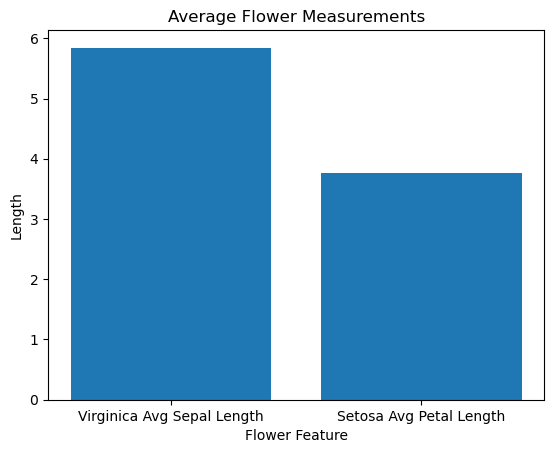

In [15]:
# code here

# Calculate averages
avg_sepal_virginica = sepal_all["SepalLengthCm"].mean()
avg_petal_setosa = petal_all["PetalLengthCm"].mean()

# Data for plotting
labels = ["Virginica Avg Sepal Length", "Setosa Avg Petal Length"]
values = [avg_sepal_virginica, avg_petal_setosa]

# Plot bar chart
plt.bar(labels, values)

plt.title("Average Flower Measurements")
plt.ylabel("Length")
plt.xlabel("Flower Feature")

plt.show()

### `Q-10:` Create the complete dataset by uisng the below datasets:
- virginica
- versicolor
- setosa
- sepal all
- petal all

This dataset should have these below column names in order:
1. Id
2. Species
3. SepalLengthCm
4. SepalWidthCm
5. PetalLengthCm
6. PetalWidthCm

Also, the dataset should be shuffled means the `Id` column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use `DataFrame.sample()` method to shuffle.

In [16]:
# code here

# Combine sepal and petal measurements
data = pd.concat([sepal_all, petal_all], axis=1)

# Create measurement dataset
data = pd.DataFrame({
    "SepalLengthCm": sepal_all["SepalLengthCm"],
    "SepalWidthCm": sepal_all["SepalWidthCm"],
    "PetalLengthCm": petal_all["PetalLengthCm"],
    "PetalWidthCm": petal_all["PetalWidthCm"]
})

# Create species column
species = pd.concat([
    pd.Series(["setosa"] * len(setosa)),
    pd.Series(["versicolor"] * len(versicolor)),
    pd.Series(["virginica"] * len(virginica))
], ignore_index=True)

# Combine dataset
final_df = pd.concat([species.rename("Species"), data], axis=1)

# Add Id column
final_df.insert(0, "Id", range(1, len(final_df)+1))

# Shuffle dataset
final_df = final_df.sample(frac=1).reset_index(drop=True)

print(final_df.head())

    Id    Species  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0  114  virginica            5.7           2.5            5.0           2.0
1  132  virginica            7.9           3.8            6.4           2.0
2   43     setosa            4.4           3.2            1.3           0.2
3  138  virginica            6.4           3.1            5.5           1.8
4   44     setosa            5.0           3.5            1.6           0.6


### `Q-11:` Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
- First create a dataset with merging the required datasets
- After that, use `groupby` to create groups based on the "Species" column.
- Then find out which are asked in this question.


The output should be like this:
```bash
Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************
```

In [17]:
# code here

# Merge sepal and petal measurements
data = pd.concat([sepal_all, petal_all], axis=1)

# Create species column
species = pd.concat([
    pd.Series(["Setosa"] * len(setosa)),
    pd.Series(["Versicolor"] * len(versicolor)),
    pd.Series(["Virginica"] * len(virginica))
], ignore_index=True)

data["Species"] = species

# Keep only needed species
data = data[data["Species"].isin(["Setosa", "Versicolor"])]

# Group by species
grouped = data.groupby("Species")

# Calculate min and max
for species_name, group in grouped:
    
    min_sepal = group["SepalWidthCm"].min()
    max_sepal = group["SepalWidthCm"].max()
    
    min_petal = group["PetalWidthCm"].min()
    max_petal = group["PetalWidthCm"].max()
    
    print(f"Minimum Sepal width of {species_name} is {min_sepal}")
    print(f"Maximum Sepal width of {species_name} is {max_sepal}")
    
    print(f"Minimum Petal width of {species_name} is {min_petal}")
    print(f"Maximum Petal width of {species_name} is {max_petal}")
    
    print("\n**************************************************\n")

Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4
Minimum Petal width of Setosa is 0.1
Maximum Petal width of Setosa is 0.6

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4
Minimum Petal width of Versicolor is 1.0
Maximum Petal width of Versicolor is 1.8

**************************************************

